In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
import seaborn as sns

# Data scaning

In [2]:
data = pd.read_csv('./dataset/train.csv')
X = data.drop(columns=['rainfall'])
y = data['rainfall']
X_cp, y_cp = X.copy(), y.copy()
X_cp.head(10)

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8
5,5,6,1022.7,20.6,18.6,16.5,12.5,79.0,81.0,0.0,20.0,15.7
6,6,7,1022.8,19.5,18.4,15.3,11.3,56.0,46.0,7.6,20.0,28.4
7,7,8,1019.7,15.8,13.6,12.7,11.8,96.0,100.0,0.0,50.0,52.8
8,8,9,1017.4,17.6,16.5,15.6,12.5,86.0,100.0,0.0,50.0,37.5
9,9,10,1025.4,16.5,14.4,12.0,8.6,77.0,84.0,1.0,50.0,38.3


In [3]:
X_cp.shape

(2190, 12)

## 1. Check Null data

In [4]:
X_cp.isna().sum()

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    0
windspeed        0
dtype: int64

There is no Null data.

## 2. Check Duplicated data 

In [5]:
X_cp.duplicated().sum()

np.int64(0)

And no duplicated data

## 3 Check cardinulity

In [6]:
X_cp.nunique()

id               2190
day               365
pressure          236
maxtemp           219
temparature       198
mintemp           199
dewpoint          218
humidity           49
cloud              78
sunshine          120
winddirection      35
windspeed         223
dtype: int64

## 4. Check label's ratio

rainfall
1    1650
0     540
Name: count, dtype: int64


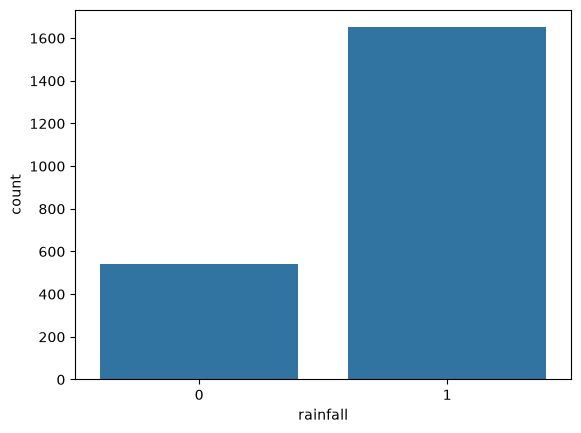

In [7]:
sns.countplot(x=y_cp)
print(y_cp.value_counts())

- Note: There is class imbalance
- insight: We can do data augmetation (augment 0 class)

# Modeling

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_cp, y_cp, random_state=42, test_size=0.3)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
lr = LogisticRegression(C=1)

In [ ]:
FOLDS = 10
total_score = 0
cv = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)
for i, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    lr.fit(X_tr, y_tr)
    pred_proba = lr.predict_proba(X_val)[:,1]
    pred = (pred_proba >= 0.5).astype(int)
    score = roc_auc_score(y_val, pred_proba)
    total_score += score
    print(f'{i+1}st fold: {np.round(score, 4)}')
print(f'mean of roc_score: {np.round(total_score / FOLDS, 4)}')

1st fold: 0.926
2st fold: 0.89
3st fold: 0.8995
4st fold: 0.8966
5st fold: 0.9066
6st fold: 0.8798
7st fold: 0.8919
8st fold: 0.925
9st fold: 0.8954
10st fold: 0.8979
mean of roc_score: 0.9009


In [16]:
pred_proba = lr.predict_proba(X_test_scaled)[:, 1]
score = roc_auc_score(y_test, pred_proba)
print(np.round(score, 4))

0.8777
